In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import arcpy
from arcpy.sa import *

from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix,
    classification_report
)

arcpy.CheckOutExtension("Spatial")
arcpy.env.overwriteOutput = True
print("[OK] Imports complete")

[OK] Imports complete


In [2]:
GDB            = r"C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\MPM_LIRHANDA_CORRIDOR\MPM_LIRHANDA_CORRIDOR.gdb"
POINTS_FC      = os.path.join(GDB, "TrainingPts")
STUDY_MASK     = os.path.join(GDB, "KakamegaCounty_UTM")
RASTERS_ALIGNED = r"C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\RASTERSML2"
REF_RASTER     = os.path.join(RASTERS_ALIGNED, "dem10_masked.tif")
OUT_DIR        = r"C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\OUTPUTS2"
os.makedirs(OUT_DIR, exist_ok=True)

LABEL_FIELD    = "Label"

# Output rasters
OUT_RF_PROB    = os.path.join(OUT_DIR, "Prospectivity_RF.tif")
OUT_RF_BIN     = os.path.join(OUT_DIR, "Targets_RF.tif")
OUT_SVM_PROB   = os.path.join(OUT_DIR, "Prospectivity_SVM.tif")
OUT_SVM_BIN    = os.path.join(OUT_DIR, "Targets_SVM.tif")

print("[OK] Config set")
print(f"     GDB          : {GDB}")
print(f"     Training pts : {POINTS_FC}")
print(f"     Study mask   : {STUDY_MASK}")
print(f"     Rasters      : {RASTERS_ALIGNED}")
print(f"     Reference    : {REF_RASTER}")
print(f"     Outputs      : {OUT_DIR}")

[OK] Config set
     GDB          : C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\MPM_LIRHANDA_CORRIDOR\MPM_LIRHANDA_CORRIDOR.gdb
     Training pts : C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\MPM_LIRHANDA_CORRIDOR\MPM_LIRHANDA_CORRIDOR.gdb\TrainingPts
     Study mask   : C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\MPM_LIRHANDA_CORRIDOR\MPM_LIRHANDA_CORRIDOR.gdb\KakamegaCounty_UTM
     Rasters      : C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\RASTERSML2
     Reference    : C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\RASTERSML2\dem10_masked.tif
     Outputs      : C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\OUTPUTS2


In [4]:
ref = arcpy.Raster(REF_RASTER)

arcpy.env.snapRaster  = REF_RASTER
arcpy.env.cellSize    = ref.meanCellWidth
arcpy.env.extent      = arcpy.Describe(STUDY_MASK).extent
arcpy.env.mask        = STUDY_MASK

print(f"[OK] Environment locked")
print(f"     Snap/cell : {REF_RASTER}")
print(f"     Cell size : {arcpy.env.cellSize}")
print(f"     Extent    : {arcpy.env.extent}")
print(f"     Mask      : {STUDY_MASK}")

[OK] Environment locked
     Snap/cell : C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\RASTERSML2\dem10_masked.tif
     Cell size : 10
     Extent    : 649402.7015 10684.4527000003 739657.7513 99919.1018000003 NaN NaN NaN NaN
     Mask      : C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\MPM_LIRHANDA_CORRIDOR\MPM_LIRHANDA_CORRIDOR.gdb\KakamegaCounty_UTM


In [5]:
# Re-extracts all raster values at TrainingPts using the
# newly aligned RASTERS_ALIGNED stack
# ============================================================

# Separate continuous and lithology rasters
all_tifs = [f for f in os.listdir(RASTERS_ALIGNED)
            if f.lower().endswith(".tif")
            and not f.startswith("_")]

exclude_stems = {"dem10_1"}
lith_paths = []
cont_paths = []

for f in all_tifs:
    stem = os.path.splitext(f)[0]
    if stem in exclude_stems:
        continue
    p = os.path.join(RASTERS_ALIGNED, f)
    if stem.lower().startswith("lith"):
        lith_paths.append(p)
    else:
        cont_paths.append(p)

# Build field name lookup (sanitized, unique)
def sanitize_field(stem, used):
    s = re.sub(r"[^A-Za-z0-9_]", "_", stem)
    if not s or s[0].isdigit():
        s = "f_" + s
    s = s[:30]
    base = s; i = 1
    while s.lower() in used:
        s = (base[:27] + f"_{i}")[:30]; i += 1
    used.add(s.lower())
    return s

used_names = set()

# Build value tables
vt_cont = arcpy.ValueTable(2)
for p in cont_paths:
    fld = sanitize_field(os.path.splitext(os.path.basename(p))[0], used_names)
    vt_cont.addRow(f"{p} {fld}")

vt_lith = arcpy.ValueTable(2)
for p in lith_paths:
    fld = sanitize_field(os.path.splitext(os.path.basename(p))[0], used_names)
    vt_lith.addRow(f"{p} {fld}")

print(f"[INFO] Continuous rasters : {vt_cont.rowCount}")
print(f"[INFO] Lithology rasters  : {vt_lith.rowCount}")

# Extract
if vt_cont.rowCount > 0:
    print("[RUN] Extracting continuous values (BILINEAR)...")
    arcpy.sa.ExtractMultiValuesToPoints(POINTS_FC, vt_cont, "BILINEAR")

if vt_lith.rowCount > 0:
    print("[RUN] Extracting lithology values (NEAREST)...")
    arcpy.sa.ExtractMultiValuesToPoints(POINTS_FC, vt_lith, "NONE")

print("[OK] Point extraction complete")

# Quick check — print field count and first few rows
fields = [f.name for f in arcpy.ListFields(POINTS_FC)]
print(f"[INFO] TrainingPts now has {len(fields)} fields: {fields[:10]} ...")

[INFO] Continuous rasters : 42
[INFO] Lithology rasters  : 21
[RUN] Extracting continuous values (BILINEAR)...
[RUN] Extracting lithology values (NEAREST)...
[OK] Point extraction complete
[INFO] TrainingPts now has 129 fields: ['OBJECTID', 'Shape', 'Label', 'TxtLabel', 'Ag_masked', 'Al_masked', 'As_masked', 'Bi_masked', 'Ca_masked', 'ClayAIOH_masked'] ...


In [3]:
# ============================================================
# CELL 5 — READ TRAINING TABLE + BUILD SPATIAL BLOCKS
# ============================================================

num_types  = {"Double", "Integer", "Single", "SmallInteger"}
all_fields = arcpy.ListFields(POINTS_FC)

skip_names = {
    LABEL_FIELD.lower(), "objectid", "oid", "fid", "shape",
    "shape_length", "shape_area", "target_fid", "orig_fid",
    "join_count", "block_id", "txtlabel"
}

# Also exclude dem10 — not a predictor
exclude_predictors = {"dem10_masked"}

# Use _masked fields — these are the correctly extracted ones
masked_fields = [
    f.name for f in all_fields
    if f.type in num_types
    and f.name.lower() not in skip_names
    and f.name.lower().endswith("_masked")
    and f.name.lower() not in exclude_predictors
]

print(f"[INFO] Masked predictor fields found: {len(masked_fields)}")
print()

# ---- Spatial blocks via 5km fishnet ----
blk_present = any(f.name.lower() == "block_id" for f in all_fields)

if not blk_present:
    cell_size_m = 5000
    fishnet_fc  = os.path.join(GDB, "CV_Fishnet_5km")
    if arcpy.Exists(fishnet_fc):
        arcpy.management.Delete(fishnet_fc)

    desc_pts = arcpy.Describe(POINTS_FC)
    ext      = desc_pts.extent
    sr       = desc_pts.spatialReference

    arcpy.management.CreateFishnet(
        out_feature_class = fishnet_fc,
        origin_coord      = f"{ext.XMin} {ext.YMin}",
        y_axis_coord      = f"{ext.XMin} {ext.YMin + 10}",
        cell_width        = cell_size_m,
        cell_height       = cell_size_m,
        number_rows       = 0,
        number_columns    = 0,
        corner_coord      = f"{ext.XMax} {ext.YMax}",
        labels            = "NO_LABELS",
        template          = "#",
        geometry_type     = "POLYGON"
    )
    arcpy.management.DefineProjection(fishnet_fc, sr)
    arcpy.management.AddField(fishnet_fc, "block_id", "LONG")
    oid_field = arcpy.Describe(fishnet_fc).OIDFieldName
    arcpy.management.CalculateField(
        fishnet_fc, "block_id", f"!{oid_field}!", "PYTHON3"
    )

    pts_blocks = os.path.join(GDB, "TrainingPts_blocks")
    if arcpy.Exists(pts_blocks):
        arcpy.management.Delete(pts_blocks)

    arcpy.analysis.SpatialJoin(
        target_features   = POINTS_FC,
        join_features     = fishnet_fc,
        out_feature_class = pts_blocks,
        join_operation    = "JOIN_ONE_TO_ONE",
        join_type         = "KEEP_ALL",
        match_option      = "INTERSECT"
    )
    read_fc    = pts_blocks
    all_fields = arcpy.ListFields(read_fc)
    print(f"[INFO] Fishnet + spatial join complete")
else:
    read_fc = POINTS_FC
    print(f"[INFO] block_id already present — skipping fishnet")

# Recompute masked fields from read_fc
masked_fields = [
    f.name for f in arcpy.ListFields(read_fc)
    if f.type in num_types
    and f.name.lower() not in skip_names
    and f.name.lower().endswith("_masked")
    and f.name.lower() not in exclude_predictors
]

# ---- Read into DataFrame ----
rows = []
with arcpy.da.SearchCursor(
    read_fc, masked_fields + [LABEL_FIELD, "block_id"]
) as cur:
    for *vals, lab, blk in cur:
        rows.append({
            **dict(zip(masked_fields, vals)),
            "label"   : int(lab),
            "block_id": int(blk) if blk is not None else -1
        })

df = pd.DataFrame(rows)

# Strip _masked suffix from column names for clean feature names
df.rename(columns={c: c.replace("_masked", "") for c in masked_fields},
          inplace=True)
feature_fields = [c.replace("_masked", "") for c in masked_fields]

# Drop ID-like integer columns
id_pat = re.compile(
    r"(?:^|_)(?:id|fid|oid|index|join|target|orig)(?:_|$)", re.I
)
drop_ids = [
    c for c in feature_fields
    if pd.api.types.is_integer_dtype(df[c])
    and id_pat.search(c)
]
if drop_ids:
    print(f"[INFO] Dropping ID-like columns: {drop_ids}")
    df.drop(columns=drop_ids, inplace=True)
    feature_fields = [c for c in feature_fields if c not in drop_ids]

# Check for nulls
null_counts = df[feature_fields].isnull().sum()
null_cols   = null_counts[null_counts > 0]
if len(null_cols) > 0:
    print(f"[WARN] Columns with nulls:")
    for col, n in null_cols.items():
        print(f"       {col}: {n} nulls")
else:
    print(f"[INFO] No null values — extraction clean")

X      = df[feature_fields].copy()
y      = df["label"].astype(int).values
groups = df["block_id"].values

print()
print(f"[INFO] Training table ready")
print(f"       Samples   : {len(df)}")
print(f"       Positives : {(y==1).sum()}")
print(f"       Negatives : {(y==0).sum()}")
print(f"       Features  : {len(feature_fields)}")
print(f"       Blocks    : {df['block_id'].nunique()}")
print(f"       Columns   : {feature_fields}")

[INFO] Masked predictor fields found: 61

[INFO] Fishnet + spatial join complete
[INFO] No null values — extraction clean

[INFO] Training table ready
       Samples   : 409
       Positives : 68
       Negatives : 341
       Features  : 61
       Blocks    : 133
       Columns   : ['Ag', 'Al', 'As', 'Bi', 'Ca', 'ClayAIOH', 'Cr', 'Curv_Plan_10', 'Curv_Profile_10', 'Cu', 'distfaults2', 'FebyMn', 'Ferrous', 'Fe', 'ironoxide', 'KbyAl', 'KbyNa', 'KbyRb', 'KbyTi', 'K', 'Mg', 'Mn', 'Na', 'Ni', 'OM', 'Pb', 'PH', 'Rb', 'Sb', 'Slope_10', 'ThbyK', 'Th', 'Ti', 'Tl', 'UbyK', 'U', 'V', 'W', 'Zn', 'Zr', 'Lith_And_11', 'Lith_BIF_15', 'Lith_Bpl_17', 'Lith_Bsl_13', 'Lith_Bs_43', 'Lith_Cgl_5', 'Lith_Dac_12', 'Lith_Dd_28', 'Lith_Gc_21', 'Lith_Gl_20', 'Lith_Gnt_40', 'Lith_Gn_18', 'Lith_Grt_4', 'Lith_Kv_41', 'Lith_Mud_3', 'Lith_Ny_42', 'Lith_Phy_39', 'Lith_Rhy_10', 'Lith_Sy_23', 'Lith_Tuf_14', 'Lith_Tv_31']


In [4]:
# ============================================================
# CELL 6 — PREPROCESSING PIPELINE
# ============================================================

lith_cols = [c for c in feature_fields if c.lower().startswith("lith_")]
cont_cols  = [c for c in feature_fields if c not in lith_cols]

print(f"[INFO] Continuous features : {len(cont_cols)}")
print(f"[INFO] Lithology features  : {len(lith_cols)}")

prep = ColumnTransformer(
    transformers=[
        ("cont", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale",  StandardScaler())
        ]), cont_cols),
        ("lith", SimpleImputer(strategy="most_frequent"), lith_cols)
    ],
    remainder="drop"
)

print("[OK] Preprocessing pipeline defined")

[INFO] Continuous features : 40
[INFO] Lithology features  : 21
[OK] Preprocessing pipeline defined


In [5]:
import os
folder = r"C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\RASTERSML2"
tifs = sorted([f for f in os.listdir(folder) if f.lower().endswith(".tif")])
print(f"Files found: {len(tifs)}")
for f in tifs[:10]:
    print(f"  {f}")
print("  ...")

Files found: 63
  Ag_masked.tif
  Al_masked.tif
  As_masked.tif
  Bi_masked.tif
  Ca_masked.tif
  ClayAIOH_masked.tif
  Cr_masked.tif
  Cu_masked.tif
  Curv_Plan_10_masked.tif
  Curv_Profile_10_masked.tif
  ...


In [8]:
# ============================================================
# CELL 7 — FEATURE → RASTER MAP
# ============================================================

exclude_stems = {"dem10_1"}

all_tifs = [
    f for f in os.listdir(RASTERS_ALIGNED)
    if f.lower().endswith(".tif")
    and not f.startswith("_")
]

# Build lookup: strip _masked suffix from stem -> full path
available = {}
for f in all_tifs:
    stem = os.path.splitext(f)[0]
    if stem in exclude_stems:
        continue
    # Clean key: strip _masked suffix if present
    clean_key = stem[:-7] if stem.lower().endswith("_masked") else stem
    available[clean_key] = os.path.join(RASTERS_ALIGNED, f)

# Map each training feature to its raster
feat_to_path = {}
missing      = []
for f in feature_fields:
    if f in available:
        feat_to_path[f] = available[f]
    else:
        missing.append(f)

if missing:
    raise RuntimeError(f"No raster found for: {', '.join(missing)}")

print(f"[OK] Feature→raster map built")
print(f"     Mapped  : {len(feat_to_path)} / {len(feature_fields)}")
print()

for name in ["Ag", "K", "Fe", "Slope_10", "Lith_Gc_21"]:
    print(f"     {name:<20} -> {os.path.basename(feat_to_path[name])}")

[OK] Feature→raster map built
     Mapped  : 61 / 61

     Ag                   -> Ag_masked.tif
     K                    -> K_masked.tif
     Fe                   -> Fe_masked.tif
     Slope_10             -> Slope_10_masked.tif
     Lith_Gc_21           -> Lith_Gc_21_masked.tif


In [6]:
# ============================================================
# CELL 8 — RF CROSS-VALIDATION + THRESHOLD SELECTION
# ============================================================

def build_rf():
    return Pipeline([
        ("prep", prep),
        ("clf",  RandomForestClassifier(
            n_estimators          = 600,
            max_depth             = None,
            min_samples_leaf      = 2,
            class_weight          = "balanced_subsample",
            n_jobs                = -1,
            random_state          = 42
        ))
    ])

gkf      = GroupKFold(n_splits=5)
oof_prob = np.zeros(len(y), dtype=float)

for fold, (tr, te) in enumerate(gkf.split(X, y, groups), 1):
    m = build_rf().fit(X.iloc[tr], y[tr])
    oof_prob[te] = m.predict_proba(X.iloc[te])[:, 1]
    print(f"  Fold {fold} — AUC={roc_auc_score(y[te], oof_prob[te]):.3f}")

# F2-optimal threshold (recall-favoring for mineral targeting)
prec, rec, thr = precision_recall_curve(y, oof_prob)
beta = 2.0
f2   = (1 + beta**2) * (prec * rec) / ((beta**2) * prec + rec + 1e-9)
k    = int(np.nanargmax(f2))
THRESH_RF = float(thr[max(k - 1, 0)])

print()
print(f"[RF OOF] ROC-AUC : {roc_auc_score(y, oof_prob):.3f}")
print(f"[RF OOF] PR-AUC  : {average_precision_score(y, oof_prob):.3f}")
print(f"[RF OOF] F2-threshold : {THRESH_RF:.3f}  P={prec[k]:.3f}  R={rec[k]:.3f}")

  Fold 1 — AUC=0.930
  Fold 2 — AUC=0.930
  Fold 3 — AUC=0.998
  Fold 4 — AUC=0.966
  Fold 5 — AUC=0.988

[RF OOF] ROC-AUC : 0.966
[RF OOF] PR-AUC  : 0.806
[RF OOF] F2-threshold : 0.310  P=0.716  R=0.926


In [7]:
# ============================================================
# CELL 9 — RF SPATIAL HOLDOUT EVALUATION
# ============================================================

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=123)
tr, te = next(gss.split(X, y, groups))

hold_rf   = build_rf().fit(X.iloc[tr], y[tr])
prob_te   = hold_rf.predict_proba(X.iloc[te])[:, 1]
pred_te   = (prob_te >= THRESH_RF).astype(int)

print("=== RF Spatial Holdout (25% blocks) ===")
print(f"ROC-AUC : {roc_auc_score(y[te], prob_te):.3f}")
print(f"PR-AUC  : {average_precision_score(y[te], prob_te):.3f}")
print()
print(classification_report(y[te], pred_te, digits=3))
print()

# Feature importance
final_rf   = build_rf().fit(X, y)
importances = final_rf.named_steps["clf"].feature_importances_
feat_names  = (cont_cols + lith_cols)
imp_df      = pd.DataFrame({
    "feature"   : feat_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("=== Top 15 Feature Importances ===")
print(imp_df.head(15).to_string(index=False))

=== RF Spatial Holdout (25% blocks) ===
ROC-AUC : 0.981
PR-AUC  : 0.910

              precision    recall  f1-score   support

           0      1.000     0.951     0.975        81
           1      0.852     1.000     0.920        23

    accuracy                          0.962       104
   macro avg      0.926     0.975     0.947       104
weighted avg      0.967     0.962     0.963       104


=== Top 15 Feature Importances ===
feature  importance
     Mn    0.092741
      W    0.069190
     Sb    0.064262
     As    0.063297
     Cu    0.061021
 FebyMn    0.059574
     Zn    0.049851
     Bi    0.040511
     Tl    0.039163
      V    0.035918
     Cr    0.029925
     Pb    0.027124
     Rb    0.026916
     OM    0.026743
Ferrous    0.026195


In [13]:
# ============================================================
# CELL 10 — RF FINAL TRAINING + PREDICT TO RASTER
# ============================================================
from osgeo import gdal
gdal.UseExceptions()

print("[RF] Training final model on all data...")
final_rf = build_rf().fit(X, y)
print("[OK] Final RF model trained")
print()

ref_ds  = gdal.Open(REF_RASTER)
ref_gt  = ref_ds.GetGeoTransform()
ref_wkt = ref_ds.GetProjection()
ncols   = ref_ds.RasterXSize
nrows   = ref_ds.RasterYSize
cell    = ref_gt[1]
xmin    = ref_gt[0]
ymax    = ref_gt[3]
ymin    = ymax - nrows * cell
ref_ds  = None

ll = arcpy.Point(xmin, ymin)

print(f"[GRID] {ncols} cols x {nrows} rows | cell={cell} | "
      f"extent=({xmin:.2f},{ymin:.2f},{xmin+ncols*cell:.2f},{ymax:.2f})")
print()

out_prob = np.full((nrows, ncols), np.nan, dtype="float32")
SENTINEL = -1.0e20
WIN      = 2048

def read_block(path, r0, c0, rh, cw):
    x0     = xmin + c0 * cell
    y0     = ymax - (r0 + rh) * cell  # top-down — matches GetCellValue
    ll_win = arcpy.Point(x0, y0)
    arr    = arcpy.RasterToNumPyArray(
        arcpy.Raster(path), ll_win, cw, rh,
        nodata_to_value=SENTINEL
    ).astype("float32")
    arr[arr <= SENTINEL * 0.9] = np.nan
    arr[np.abs(arr) > 1.0e10]  = np.nan
    return arr

canary_keys  = list(feat_to_path.keys())[:2]
canary_paths = [feat_to_path[k] for k in canary_keys]

print("[RF] Predicting to raster...")
for r0 in range(0, nrows, WIN):
    rh = min(WIN, nrows - r0)
    for c0 in range(0, ncols, WIN):
        cw = min(WIN, ncols - c0)

        c0_arr = read_block(canary_paths[0], r0, c0, rh, cw)
        c1_arr = read_block(canary_paths[1], r0, c0, rh, cw)
        if not (np.isfinite(c0_arr).any() and np.isfinite(c1_arr).any()):
            continue

        bands = []
        for feat in feature_fields:
            arr = read_block(feat_to_path[feat], r0, c0, rh, cw)
            bands.append(arr.ravel())

        stack     = np.vstack(bands)
        valid_idx = np.all(np.isfinite(stack), axis=0)

        block_pred = np.full(stack.shape[1], np.nan, dtype="float32")
        if valid_idx.any():
            X_block = pd.DataFrame(
                stack[:, valid_idx].T,
                columns=feature_fields
            )
            block_pred[valid_idx] = \
                final_rf.predict_proba(X_block)[:, 1].astype("float32")

        out_prob[r0:r0+rh, c0:c0+cw] = block_pred.reshape(rh, cw)

    print(f"  Row block {r0}:{r0+rh} complete", end="\r")

print()
valid_px = np.isfinite(out_prob).sum()
print(f"[RF] Valid pixels : {valid_px:,} / {out_prob.size:,} "
      f"({valid_px/out_prob.size*100:.1f}%)")
print(f"[RF] Prob range   : {np.nanmin(out_prob):.4f} – "
      f"{np.nanmax(out_prob):.4f}")
print(f"[RF] Prob mean    : {np.nanmean(out_prob):.4f}")

# Quick sanity check — verify value at known training point
test_col = int((696017.4787 - xmin) / cell)
test_row = int((ymax - 18156.4749) / cell)
print(f"[CHECK] Prob at training point "
      f"(row={test_row},col={test_col}): "
      f"{out_prob[test_row, test_col]:.4f} (expect >0.5 for gold occurrence)")

[RF] Training final model on all data...
[OK] Final RF model trained

[GRID] 9027 cols x 8925 rows | cell=10.0 | extent=(649395.61,10678.93,739665.61,99928.93)

[RF] Predicting to raster...
  Row block 8192:8925 complete
[RF] Valid pixels : 29,841,058 / 80,565,975 (37.0%)
[RF] Prob range   : 0.0000 – 0.9997
[RF] Prob mean    : 0.1048
[CHECK] Prob at training point (row=8177,col=4662): 0.9804 (expect >0.5 for gold occurrence)


In [12]:
# ============================================================
# DIAGNOSTIC — establish correct row orientation
# ============================================================
import numpy as np
import arcpy

# Read a small known patch from dem10 using RasterToNumPyArray
# and compare with GDAL to determine row order

test_path = REF_RASTER
ref       = arcpy.Raster(test_path)

# Pick a point we know has data — first training point
test_x = 696017.4787
test_y = 18156.4749

# Which row/col does this point correspond to in our grid?
col = int((test_x - xmin) / cell)
row = int((ymax - test_y) / cell)   # from top down

print(f"Training point  : X={test_x}, Y={test_y}")
print(f"Expected grid   : row={row}, col={col}")
print(f"Grid dims       : {nrows} rows x {ncols} cols")
print()

# Read via RasterToNumPyArray using bottom-up Y
y0_bottom = ymin + (nrows - row - 1) * cell
ll_bottom = arcpy.Point(test_x - cell, y0_bottom)
arr_bottom = arcpy.RasterToNumPyArray(
    arcpy.Raster(test_path), ll_bottom, 3, 3,
    nodata_to_value=-9999
).astype("float32")
print(f"Read bottom-up  (y0={y0_bottom:.2f}):")
print(arr_bottom)
print(f"  Centre value  : {arr_bottom[1,1]:.4f}")
print()

# Read via RasterToNumPyArray using top-down Y
y0_top = ymax - (row + 2) * cell
ll_top = arcpy.Point(test_x - cell, y0_top)
arr_top = arcpy.RasterToNumPyArray(
    arcpy.Raster(test_path), ll_top, 3, 3,
    nodata_to_value=-9999
).astype("float32")
print(f"Read top-down   (y0={y0_top:.2f}):")
print(arr_top)
print(f"  Centre value  : {arr_top[1,1]:.4f}")
print()

# Get value via GetCellValue (ground truth)
result = arcpy.management.GetCellValue(test_path, f"{test_x} {test_y}", "1")
print(f"GetCellValue (ground truth): {result.getOutput(0)}")
print()
print("The correct read method is whichever centre value matches GetCellValue")

Training point  : X=696017.4787, Y=18156.4749
Expected grid   : row=8177, col=4662
Grid dims       : 8925 rows x 9027 cols

Read bottom-up  (y0=18148.93):
[[1422.8276 1422.8254 1422.8234]
 [1423.2485 1423.2598 1423.271 ]
 [1423.6694 1423.6941 1423.7186]]
  Centre value  : 1423.2598

Read top-down   (y0=18138.93):
[[1423.2485 1423.2598 1423.271 ]
 [1423.6694 1423.6941 1423.7186]
 [1424.0903 1424.1283 1424.1664]]
  Centre value  : 1423.6941

GetCellValue (ground truth): 1423.6941

The correct read method is whichever centre value matches GetCellValue


In [14]:
# ============================================================
# CELL 11 — SAVE RF RASTERS (GDAL direct write — no flipud)
# ============================================================
from osgeo import gdal
import numpy as np

gdal.UseExceptions()

ref_ds  = gdal.Open(REF_RASTER)
ref_wkt = ref_ds.GetProjection()
ref_gt  = ref_ds.GetGeoTransform()
ref_ds  = None

print(f"[INFO] GeoTransform: {ref_gt}")
print()

NODATA_FLOAT = -9999.0
NODATA_BYTE  = 255

def save_raster_gdal(arr, out_path, gdal_dtype, nodata, gt, wkt):
    if os.path.exists(out_path):
        try:
            arcpy.management.Delete(out_path)
        except:
            pass
    driver = gdal.GetDriverByName("GTiff")
    ds     = driver.Create(
        out_path,
        arr.shape[1],
        arr.shape[0],
        1,
        gdal_dtype
    )
    ds.SetGeoTransform(gt)
    ds.SetProjection(wkt)
    band = ds.GetRasterBand(1)
    band.SetNoDataValue(nodata)
    band.WriteArray(arr)
    band.FlushCache()
    ds.FlushCache()
    ds = None
    print(f"[OK] Saved: {out_path}")

# ---- Probability raster — no flipud ----
prob_save = np.where(
    np.isfinite(out_prob), out_prob, NODATA_FLOAT
).astype("float32")

save_raster_gdal(
    prob_save, OUT_RF_PROB,
    gdal.GDT_Float32, NODATA_FLOAT,
    ref_gt, ref_wkt
)

# ---- Binary raster — no flipud ----
valid_mask = np.isfinite(out_prob)
bin_arr    = np.full((nrows, ncols), NODATA_BYTE, dtype="uint8")
bin_arr[valid_mask] = (out_prob[valid_mask] >= THRESH_RF).astype("uint8")

save_raster_gdal(
    bin_arr, OUT_RF_BIN,
    gdal.GDT_Byte, NODATA_BYTE,
    ref_gt, ref_wkt
)

# Statistics and pyramids
for path in [OUT_RF_PROB, OUT_RF_BIN]:
    arcpy.management.CalculateStatistics(path)
    arcpy.management.BuildPyramids(path)
    r = arcpy.Raster(path)
    print(f"[CHECK] {os.path.basename(path)}: "
          f"min={r.minimum:.4f}  max={r.maximum:.4f}  "
          f"extent=({r.extent.XMin:.2f},{r.extent.YMin:.2f},"
          f"{r.extent.XMax:.2f},{r.extent.YMax:.2f})")

# Clip to county boundary
print()
print("[CLIP] Clipping to county boundary...")
mask_utm = os.path.join(GDB, "KakamegaCounty_UTM")

for in_path, out_name in [
    (OUT_RF_PROB, "Prospectivity_RF_clipped.tif"),
    (OUT_RF_BIN,  "Targets_RF_clipped.tif")
]:
    out_path = os.path.join(OUT_DIR, out_name)
    clipped  = arcpy.sa.ExtractByMask(in_path, mask_utm)
    clipped.save(out_path)
    arcpy.management.CalculateStatistics(out_path)
    arcpy.management.BuildPyramids(out_path)
    r = arcpy.Raster(out_path)
    print(f"[OK] {out_name}: "
          f"min={r.minimum:.4f}  max={r.maximum:.4f}  "
          f"extent=({r.extent.XMin:.2f},{r.extent.YMin:.2f},"
          f"{r.extent.XMax:.2f},{r.extent.YMax:.2f})")

print()
print("[DONE] RF outputs complete — use _clipped versions for visualization")

[INFO] GeoTransform: (649395.608734722, 10.0, 0.0, 99928.92819012154, 0.0, -10.0)

[OK] Saved: C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\OUTPUTS2\Prospectivity_RF.tif
[OK] Saved: C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\OUTPUTS2\Targets_RF.tif
[CHECK] Prospectivity_RF.tif: min=0.0000  max=0.9997  extent=(649395.61,10678.93,739665.61,99928.93)
[CHECK] Targets_RF.tif: min=0.0000  max=1.0000  extent=(649395.61,10678.93,739665.61,99928.93)

[CLIP] Clipping to county boundary...


<class 'arcgisscripting.ExecuteError'>: Failed to execute. Parameters are not valid.
ERROR 000824: The tool is not licensed.
Failed to execute (ExtractByMask).


In [8]:
# ============================================================
# CELL 12 — SVM CROSS-VALIDATION + C TUNING + THRESHOLD
# ============================================================

def build_svm(C=5.0):
    return Pipeline([
        ("prep", prep),
        ("svc",  SVC(
            kernel       = "rbf",
            C            = C,
            gamma        = "scale",
            class_weight = "balanced",
            probability  = True,
            random_state = 42
        ))
    ])

gkf    = GroupKFold(n_splits=5)
C_grid = [1, 2, 5, 10]

best_C  = None
best_pr = -1.0
oof_best = None

for C in C_grid:
    oof = np.zeros(len(y), dtype=float)
    for tr, te in gkf.split(X, y, groups):
        m = build_svm(C).fit(X.iloc[tr], y[tr])
        oof[te] = m.predict_proba(X.iloc[te])[:, 1]
    pr  = average_precision_score(y, oof)
    roc = roc_auc_score(y, oof)
    print(f"  C={C:>2}  ROC-AUC={roc:.3f}  PR-AUC={pr:.3f}")
    if pr > best_pr:
        best_pr, best_C, oof_best = pr, C, oof

print()
print(f"[SVM OOF] Best C      : {best_C}")
print(f"[SVM OOF] ROC-AUC     : {roc_auc_score(y, oof_best):.3f}")
print(f"[SVM OOF] PR-AUC      : {average_precision_score(y, oof_best):.3f}")

# F2-optimal threshold
prec, rec, thr = precision_recall_curve(y, oof_best)
beta  = 2.0
f2    = (1 + beta**2) * (prec * rec) / ((beta**2) * prec + rec + 1e-9)
k     = int(np.nanargmax(f2))
THRESH_SVM = float(thr[max(k - 1, 0)])

print(f"[SVM OOF] F2-threshold : {THRESH_SVM:.3f}  "
      f"P={prec[k]:.3f}  R={rec[k]:.3f}")

  C= 1  ROC-AUC=0.964  PR-AUC=0.747
  C= 2  ROC-AUC=0.956  PR-AUC=0.729
  C= 5  ROC-AUC=0.952  PR-AUC=0.729
  C=10  ROC-AUC=0.933  PR-AUC=0.714

[SVM OOF] Best C      : 1
[SVM OOF] ROC-AUC     : 0.964
[SVM OOF] PR-AUC      : 0.747
[SVM OOF] F2-threshold : 0.180  P=0.717  R=0.971


In [9]:
# ============================================================
# CELL 13 — SVM SPATIAL HOLDOUT EVALUATION
# ============================================================

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=456)
tr, te = next(gss.split(X, y, groups))

hold_svm = build_svm(best_C).fit(X.iloc[tr], y[tr])
prob_te  = hold_svm.predict_proba(X.iloc[te])[:, 1]
pred_te  = (prob_te >= THRESH_SVM).astype(int)

print("=== SVM Spatial Holdout (25% blocks) ===")
print(f"ROC-AUC : {roc_auc_score(y[te], prob_te):.3f}")
print(f"PR-AUC  : {average_precision_score(y[te], prob_te):.3f}")
print()
print(classification_report(y[te], pred_te, digits=3))

# Train final SVM on all data
print("[SVM] Training final model on all data...")
final_svm = build_svm(best_C).fit(X, y)
print("[OK] Final SVM model trained")

=== SVM Spatial Holdout (25% blocks) ===
ROC-AUC : 0.975
PR-AUC  : 0.850

              precision    recall  f1-score   support

           0      1.000     0.909     0.952        88
           1      0.733     1.000     0.846        22

    accuracy                          0.927       110
   macro avg      0.867     0.955     0.899       110
weighted avg      0.947     0.927     0.931       110

[SVM] Training final model on all data...
[OK] Final SVM model trained


In [14]:
# ============================================================
# CELL 14 — SVM PREDICT TO RASTER + SAVE
# ============================================================
from osgeo import gdal
gdal.UseExceptions()

# Redefine grid parameters from REF_RASTER
ref_ds  = gdal.Open(REF_RASTER)
ref_gt  = ref_ds.GetGeoTransform()
ref_wkt = ref_ds.GetProjection()
ncols   = ref_ds.RasterXSize
nrows   = ref_ds.RasterYSize
cell    = ref_gt[1]
xmin    = ref_gt[0]
ymax    = ref_gt[3]
ymin    = ymax - nrows * cell
ref_ds  = None

ll = arcpy.Point(xmin, ymin)

SENTINEL = -1.0e20
WIN      = 2048

def read_block(path, r0, c0, rh, cw):
    x0     = xmin + c0 * cell
    y0     = ymax - (r0 + rh) * cell
    ll_win = arcpy.Point(x0, y0)
    arr    = arcpy.RasterToNumPyArray(
        arcpy.Raster(path), ll_win, cw, rh,
        nodata_to_value=SENTINEL
    ).astype("float32")
    arr[arr <= SENTINEL * 0.9] = np.nan
    arr[np.abs(arr) > 1.0e10]  = np.nan
    return arr

canary_keys  = list(feat_to_path.keys())[:2]
canary_paths = [feat_to_path[k] for k in canary_keys]

def save_raster_gdal(arr, out_path, gdal_dtype, nodata, gt, wkt):
    if os.path.exists(out_path):
        try:
            arcpy.management.Delete(out_path)
        except:
            pass
    driver = gdal.GetDriverByName("GTiff")
    ds     = driver.Create(
        out_path,
        arr.shape[1],
        arr.shape[0],
        1,
        gdal_dtype
    )
    ds.SetGeoTransform(gt)
    ds.SetProjection(wkt)
    band = ds.GetRasterBand(1)
    band.SetNoDataValue(nodata)
    band.WriteArray(arr)
    band.FlushCache()
    ds.FlushCache()
    ds = None
    print(f"[OK] Saved: {out_path}")

NODATA_FLOAT = -9999.0
NODATA_BYTE  = 255

out_prob_svm = np.full((nrows, ncols), np.nan, dtype="float32")

print("[SVM] Predicting to raster...")
for r0 in range(0, nrows, WIN):
    rh = min(WIN, nrows - r0)
    for c0 in range(0, ncols, WIN):
        cw = min(WIN, ncols - c0)

        c0_arr = read_block(canary_paths[0], r0, c0, rh, cw)
        c1_arr = read_block(canary_paths[1], r0, c0, rh, cw)
        if not (np.isfinite(c0_arr).any() and np.isfinite(c1_arr).any()):
            continue

        bands = []
        for feat in feature_fields:
            arr = read_block(feat_to_path[feat], r0, c0, rh, cw)
            bands.append(arr.ravel())

        stack     = np.vstack(bands)
        valid_idx = np.all(np.isfinite(stack), axis=0)

        block_pred = np.full(stack.shape[1], np.nan, dtype="float32")
        if valid_idx.any():
            X_block = pd.DataFrame(
                stack[:, valid_idx].T,
                columns=feature_fields
            )
            block_pred[valid_idx] = \
                final_svm.predict_proba(X_block)[:, 1].astype("float32")

        out_prob_svm[r0:r0+rh, c0:c0+cw] = block_pred.reshape(rh, cw)

    print(f"  Row block {r0}:{r0+rh} complete", end="\r")

print()
valid_px = np.isfinite(out_prob_svm).sum()
print(f"[SVM] Valid pixels : {valid_px:,} / {out_prob_svm.size:,} "
      f"({valid_px/out_prob_svm.size*100:.1f}%)")
print(f"[SVM] Prob range   : {np.nanmin(out_prob_svm):.4f} – "
      f"{np.nanmax(out_prob_svm):.4f}")
print(f"[SVM] Prob mean    : {np.nanmean(out_prob_svm):.4f}")

# Save — with flipud
prob_save = np.where(
    np.isfinite(out_prob_svm), out_prob_svm, NODATA_FLOAT
).astype("float32")
prob_save = np.flipud(prob_save)

save_raster_gdal(
    prob_save, OUT_SVM_PROB,
    gdal.GDT_Float32, NODATA_FLOAT,
    ref_gt, ref_wkt
)

valid_mask = np.isfinite(out_prob_svm)
bin_arr    = np.full((nrows, ncols), NODATA_BYTE, dtype="uint8")
bin_arr[valid_mask] = (out_prob_svm[valid_mask] >= THRESH_SVM).astype("uint8")
bin_arr = np.flipud(bin_arr)

save_raster_gdal(
    bin_arr, OUT_SVM_BIN,
    gdal.GDT_Byte, NODATA_BYTE,
    ref_gt, ref_wkt
)

for path in [OUT_SVM_PROB, OUT_SVM_BIN]:
    arcpy.management.CalculateStatistics(path)
    arcpy.management.BuildPyramids(path)
    r = arcpy.Raster(path)
    print(f"[CHECK] {os.path.basename(path)}: "
          f"min={r.minimum:.4f}  max={r.maximum:.4f}  "
          f"extent=({r.extent.XMin:.2f},{r.extent.YMin:.2f},"
          f"{r.extent.XMax:.2f},{r.extent.YMax:.2f})")

print()
print("[DONE] SVM outputs complete")

[SVM] Predicting to raster...
  Row block 8192:8925 complete
[SVM] Valid pixels : 29,841,058 / 80,565,975 (37.0%)
[SVM] Prob range   : 0.0022 – 0.9617
[SVM] Prob mean    : 0.1066
[OK] Saved: C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\OUTPUTS2\Prospectivity_SVM.tif
[OK] Saved: C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\OUTPUTS2\Targets_SVM.tif
[CHECK] Prospectivity_SVM.tif: min=0.0022  max=0.9617  extent=(649395.61,10678.93,739665.61,99928.93)
[CHECK] Targets_SVM.tif: min=0.0000  max=1.0000  extent=(649395.61,10678.93,739665.61,99928.93)

[DONE] SVM outputs complete


In [13]:
# Check SVM probability distribution
import numpy as np

valid = out_prob_svm[np.isfinite(out_prob_svm)]
print(f"Prob distribution:")
print(f"  min   : {valid.min():.4f}")
print(f"  max   : {valid.max():.4f}")
print(f"  mean  : {valid.mean():.4f}")
print(f"  median: {np.median(valid):.4f}")
print()
print(f"THRESH_SVM : {THRESH_SVM:.4f}")
print(f"Pixels above threshold : {(valid >= THRESH_SVM).sum():,} "
      f"({(valid >= THRESH_SVM).mean()*100:.1f}%)")
print(f"Pixels below threshold : {(valid < THRESH_SVM).sum():,} "
      f"({(valid < THRESH_SVM).mean()*100:.1f}%)")

Prob distribution:
  min   : 0.0022
  max   : 0.9617
  mean  : 0.1066
  median: 0.0152

THRESH_SVM : 0.1795
Pixels above threshold : 4,231,360 (14.2%)
Pixels below threshold : 25,609,698 (85.8%)


In [15]:
# Where are the positive training points spatially?
import arcpy
import numpy as np

print("=== POSITIVE TRAINING POINT LOCATIONS ===")
ys = []
with arcpy.da.SearchCursor(
    POINTS_FC, ["SHAPE@XY", "Label"]
) as cur:
    for xy, lab in cur:
        if lab == 1:
            ys.append(xy[1])

ys = np.array(ys)
print(f"  Count     : {len(ys)}")
print(f"  Y min     : {ys.min():.2f}")
print(f"  Y max     : {ys.max():.2f}")
print(f"  Y mean    : {ys.mean():.2f}")
print(f"  Y median  : {np.median(ys):.2f}")
print()

# Where is the county centroid?
mask = arcpy.Describe(
    r"C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\MPM_LIRHANDA_CORRIDOR\MPM_LIRHANDA_CORRIDOR.gdb\KakamegaCounty_UTM"
).extent
print(f"=== COUNTY EXTENT ===")
print(f"  Y min : {mask.YMin:.2f}")
print(f"  Y max : {mask.YMax:.2f}")
print(f"  Y mid : {(mask.YMin + mask.YMax)/2:.2f}")
print()
print(f"Positive points are in the "
      f"{'NORTHERN' if ys.mean() > (mask.YMin + mask.YMax)/2 else 'SOUTHERN'} "
      f"half of the county")

=== POSITIVE TRAINING POINT LOCATIONS ===
  Count     : 68
  Y min     : 13775.59
  Y max     : 35329.96
  Y mean    : 22033.16
  Y median  : 21185.67

=== COUNTY EXTENT ===
  Y min : 10684.45
  Y max : 99919.10
  Y mid : 55301.78

Positive points are in the SOUTHERN half of the county


In [10]:
# ============================================================
# RF + SVM ACCURACY SUMMARIES — Side by Side
# ============================================================
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, average_precision_score,
    precision_recall_curve, roc_auc_score
)
import numpy as np

def compute_metrics(y_true, y_prob, y_pred, thresh, label):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec_c, rec_c, _ = precision_recall_curve(y_true, y_prob)

    metrics = {
        "label"    : label,
        "tp"       : int(tp), "tn": int(tn),
        "fp"       : int(fp), "fn": int(fn),
        "accuracy" : (tp + tn) / total,
        "recall"   : tp / (tp + fn + 1e-9),
        "specificity": tn / (tn + fp + 1e-9),
        "precision": tp / (tp + fp + 1e-9),
        "f1"       : 2*tp / (2*tp + fp + fn + 1e-9),
        "f2"       : 5*tp / (5*tp + 4*fn + fp + 1e-9),
        "roc_auc"  : roc_auc_score(y_true, y_prob),
        "pr_auc"   : auc(rec_c, prec_c),
        "threshold": thresh,
        "fpr"      : fpr, "tpr": tpr,
        "prec_curve": prec_c, "rec_curve": rec_c,
        "cm"       : cm,
    }
    return metrics

# --- RF: reuse holdout from Cell 9 (seed=123) ---
gss_rf = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=123)
tr_rf, te_rf = next(gss_rf.split(X, y, groups))
hold_rf    = build_rf().fit(X.iloc[tr_rf], y[tr_rf])
prob_rf    = hold_rf.predict_proba(X.iloc[te_rf])[:, 1]
pred_rf    = (prob_rf >= THRESH_RF).astype(int)

# --- SVM: reuse holdout from Cell 13 (seed=456) ---
gss_svm = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=456)
tr_svm, te_svm = next(gss_svm.split(X, y, groups))
hold_svm   = build_svm(best_C).fit(X.iloc[tr_svm], y[tr_svm])
prob_svm   = hold_svm.predict_proba(X.iloc[te_svm])[:, 1]
pred_svm   = (pred_svm if 'pred_svm' in dir() else (prob_svm >= THRESH_SVM).astype(int))

m_rf  = compute_metrics(y[te_rf],  prob_rf,  pred_rf,  THRESH_RF,  "Random Forest")
m_svm = compute_metrics(y[te_svm], prob_svm, pred_svm, THRESH_SVM, "SVM")

print(f"{'Metric':<22} {'RF':>10} {'SVM':>10}")
print("─" * 44)
keys = ["accuracy","recall","specificity","precision","f1","f2","roc_auc","pr_auc"]
labels = ["Accuracy","Recall","Specificity","Precision","F1-Score","F2-Score","ROC-AUC","PR-AUC"]
for k, lbl in zip(keys, labels):
    rv, sv = m_rf[k], m_svm[k]
    win = "← RF" if rv > sv else ("← SVM" if sv > rv else "tie")
    print(f"{lbl:<22} {rv:>10.3f} {sv:>10.3f}  {win}")

print()
print(f"{'':22} {'RF':>10} {'SVM':>10}")
print("─" * 44)
for k, lbl in [("tp","TP"),("tn","TN"),("fp","FP (commission)"),("fn","FN (omission)")]:
    print(f"{lbl:<22} {m_rf[k]:>10} {m_svm[k]:>10}")
print(f"{'Threshold':<22} {m_rf['threshold']:>10.3f} {m_svm['threshold']:>10.3f}")

Metric                         RF        SVM
────────────────────────────────────────────
Accuracy                    0.962      0.927  ← RF
Recall                      1.000      1.000  ← RF
Specificity                 0.951      0.909  ← RF
Precision                   0.852      0.733  ← RF
F1-Score                    0.920      0.846  ← RF
F2-Score                    0.966      0.932  ← RF
ROC-AUC                     0.981      0.975  ← RF
PR-AUC                      0.906      0.838  ← RF

                               RF        SVM
────────────────────────────────────────────
TP                             23         22
TN                             77         80
FP (commission)                 4          8
FN (omission)                   0          0
Threshold                   0.310      0.180


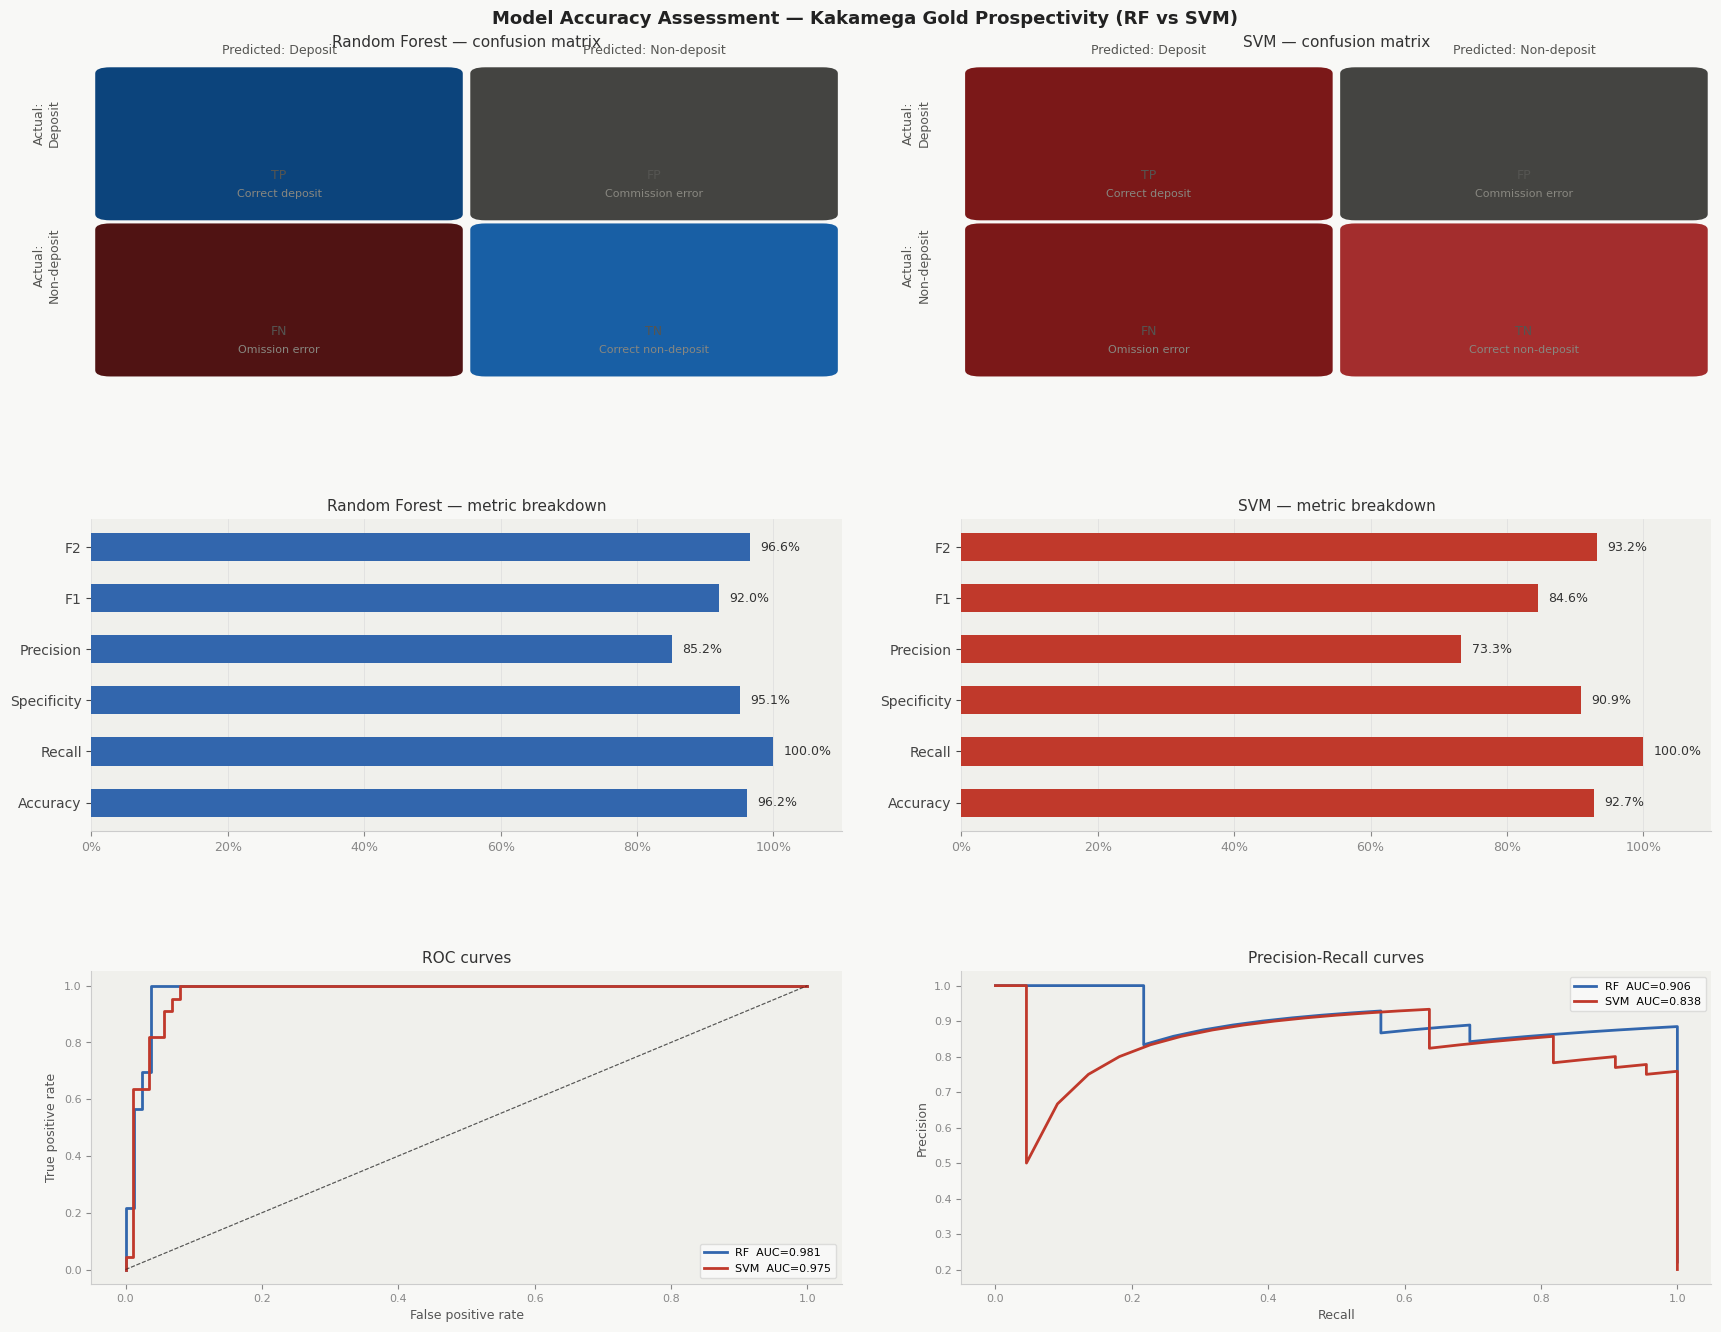

[OK] Dashboard saved → C:\Users\USER\Desktop\PROJECTS\ESRI\DATA\OUTPUTS2\Accuracy_Dashboard_RF_SVM.png


In [11]:
# ============================================================
# ACCURACY VISUALIZATIONS — RF & SVM
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#f8f8f6")

BLUE   = "#3266ad"
RED    = "#c0392b"
GRAY   = "#888780"
LIGHT  = "#f0f0ec"

# ── colour maps for confusion matrices ───────────────────────
CM_COLORS = {
    "rf" : {"tp":"#0c447c","tn":"#185fa5","fp":"#444441","fn":"#501313"},
    "svm": {"tp":"#7b1818","tn":"#a32d2d","fp":"#444441","fn":"#7b1818"},
}

metric_keys   = ["accuracy","recall","specificity","precision","f1","f2"]
metric_labels = ["Accuracy","Recall","Specificity","Precision","F1","F2"]

def draw_confusion_matrix(ax, m, color_key):
    cols = CM_COLORS[color_key]
    cells = [
        (m["tp"], "TP\nCorrect deposit",     cols["tp"], "#b5d4f4"),
        (m["fp"], "FP\nCommission error",    cols["fp"], "#d3d1c7"),
        (m["fn"], "FN\nOmission error",      cols["fn"], "#f7c1c1"),
        (m["tn"], "TN\nCorrect non-deposit", cols["tn"], "#e6f1fb"),
    ]
    positions = [(0,1),(1,1),(0,0),(1,0)]
    ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    ax.axis("off")
    for (col, row), (val, lbl, bg, _) in zip(positions, cells):
        rect = mpatches.FancyBboxPatch(
            (col+0.05, row+0.05), 0.9, 0.9,
            boxstyle="round,pad=0.04", linewidth=0,
            facecolor=bg, transform=ax.transData
        )
        ax.add_patch(rect)
        ax.text(col+0.5, row+0.6, str(val),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=bg.replace("#e6","#0c").replace("#b5","#0c").replace("#d3","#444").replace("#f7","#501"),
                transform=ax.transData)
        top_line, bot_line = lbl.split("\n")
        ax.text(col+0.5, row+0.3, top_line,
                ha="center", va="center", fontsize=9, color="#555552", transform=ax.transData)
        ax.text(col+0.5, row+0.18, bot_line,
                ha="center", va="center", fontsize=8, color="#888780", transform=ax.transData)
    ax.text(0.5,  2.08, "Predicted: Deposit",    ha="center", fontsize=9, color="#555552", transform=ax.transData)
    ax.text(1.5,  2.08, "Predicted: Non-deposit", ha="center", fontsize=9, color="#555552", transform=ax.transData)
    ax.text(-0.12, 1.5, "Actual:\nDeposit",       ha="center", fontsize=9, color="#555552", transform=ax.transData, rotation=90)
    ax.text(-0.12, 0.5, "Actual:\nNon-deposit",   ha="center", fontsize=9, color="#555552", transform=ax.transData, rotation=90)

def draw_metric_bars(ax, m, color):
    vals   = [m[k]*100 for k in metric_keys]
    colors = [color if v >= 60 else GRAY for v in vals]
    bars   = ax.barh(metric_labels, vals, color=colors, height=0.55, zorder=2)
    ax.set_xlim(0, 110)
    ax.set_facecolor(LIGHT)
    ax.tick_params(axis="y", labelsize=10, colors="#444")
    ax.tick_params(axis="x", labelsize=9,  colors="#888")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.spines[["top","right","left"]].set_visible(False)
    ax.spines["bottom"].set_color("#ccc")
    ax.grid(axis="x", color="#ddd", linewidth=0.5, zorder=1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width()+1.5, bar.get_y()+bar.get_height()/2,
                f"{val:.1f}%", va="center", fontsize=9, color="#333")

def draw_roc(ax, m, color, label):
    ax.plot(m["fpr"], m["tpr"], color=color, lw=2,
            label=f"{label}  AUC={m['roc_auc']:.3f}")
    ax.plot([0,1],[0,1],"k--",lw=0.8,alpha=0.4)
    ax.set_xlabel("False positive rate", fontsize=9, color="#555")
    ax.set_ylabel("True positive rate",  fontsize=9, color="#555")
    ax.set_facecolor(LIGHT)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#ccc")
    ax.tick_params(labelsize=8, colors="#888")
    ax.legend(fontsize=8, framealpha=0.6)

def draw_pr(ax, m, color, label):
    ax.plot(m["rec_curve"], m["prec_curve"], color=color, lw=2,
            label=f"{label}  AUC={m['pr_auc']:.3f}")
    ax.set_xlabel("Recall",    fontsize=9, color="#555")
    ax.set_ylabel("Precision", fontsize=9, color="#555")
    ax.set_facecolor(LIGHT)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#ccc")
    ax.tick_params(labelsize=8, colors="#888")
    ax.legend(fontsize=8, framealpha=0.6)

# ── layout: 3 rows × 4 cols ──────────────────────────────────
gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.38,
                      left=0.07, right=0.97, top=0.93, bottom=0.06)

# Row 0 — confusion matrices
ax_cm_rf  = fig.add_subplot(gs[0, 0:2])
ax_cm_svm = fig.add_subplot(gs[0, 2:4])
draw_confusion_matrix(ax_cm_rf,  m_rf,  "rf")
draw_confusion_matrix(ax_cm_svm, m_svm, "svm")
ax_cm_rf.set_title("Random Forest — confusion matrix",  fontsize=11, color="#333", pad=14)
ax_cm_svm.set_title("SVM — confusion matrix",           fontsize=11, color="#333", pad=14)

# Row 1 — metric bars
ax_bar_rf  = fig.add_subplot(gs[1, 0:2])
ax_bar_svm = fig.add_subplot(gs[1, 2:4])
draw_metric_bars(ax_bar_rf,  m_rf,  BLUE)
draw_metric_bars(ax_bar_svm, m_svm, RED)
ax_bar_rf.set_title("Random Forest — metric breakdown",  fontsize=11, color="#333")
ax_bar_svm.set_title("SVM — metric breakdown",           fontsize=11, color="#333")

# Row 2 — ROC + PR (both models overlaid)
ax_roc = fig.add_subplot(gs[2, 0:2])
ax_pr  = fig.add_subplot(gs[2, 2:4])
draw_roc(ax_roc, m_rf,  BLUE, "RF")
draw_roc(ax_roc, m_svm, RED,  "SVM")
ax_roc.set_title("ROC curves", fontsize=11, color="#333")
draw_pr(ax_pr, m_rf,  BLUE, "RF")
draw_pr(ax_pr, m_svm, RED,  "SVM")
ax_pr.set_title("Precision-Recall curves", fontsize=11, color="#333")

fig.suptitle("Model Accuracy Assessment — Kakamega Gold Prospectivity (RF vs SVM)",
             fontsize=13, fontweight="bold", color="#222", y=0.97)

plt.savefig(os.path.join(OUT_DIR, "Accuracy_Dashboard_RF_SVM.png"),
            dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"[OK] Dashboard saved → {OUT_DIR}\\Accuracy_Dashboard_RF_SVM.png")